In [1]:
# load the required libraries for data analysis and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset 
The dataset was loaded using the function pd.read_csv()
function and few rows were printed using the head( function in python)

# Data Collection
The dataset was downloaded from Kaggle dataset https://www.kaggle.com/datasets/uciml/iris?select=Iris.csv


In [ ]:
#Reading the dataset
iris_data = pd.read_csv("Iris.csv")
print(iris_data.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# Data Manipulation and Inspection
The dataset Has 150 observations and 6 columns:
the columns include;
**ID** integer: Has unique inex of the observation
**SepalLengrhCm** Float: variable shows the sepal length in centimeter
**SepalWindthCm** Float: variable shows the sepal width in centimeter
**PetalLengrhCm** Float: variable shows the Petal length in centimeter
**PetalWindthCm** Float: variable shows the PeTal width in centimeter

50 observations were selected from the 3 Species thats 
Iris-setosa
Iris-versicolor
Iris-virginica 

A table showing some of the major statistical summaries was include in the output section below
The dataset was clean with no missing values


In [21]:
# inspect the dataset
print(iris_data.info())
print(iris_data.describe())
print(iris_data['Species'].value_counts())

#check for missing values
print('The total missing values',iris_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000    

# Exploratory Data analysis and Visualization
The graphs below show the distribution of each variable that is SepalLength, width and PetalLength and width of the 
three flower species.
**SepalLengthCm**
The data is spread roughly between 4 cm and 8 cm. The distribution looks somewhat right-skewed, meaning most flowers have shorter sepals.
**SepalWidththCm**
Most values are centered around 3 cm, forming a bell-shaped (normal-like) distribution. Few flowers have very narrow or very wide sepals.
**PetalLengththCm**
The data is bimodal — two clear peaks — indicating that different species have distinct petal lengths
**PetalWidththCm**
Also bimodal, with one cluster near 0.2 cm and another around 1.5–2 cm, again reflecting species differences.

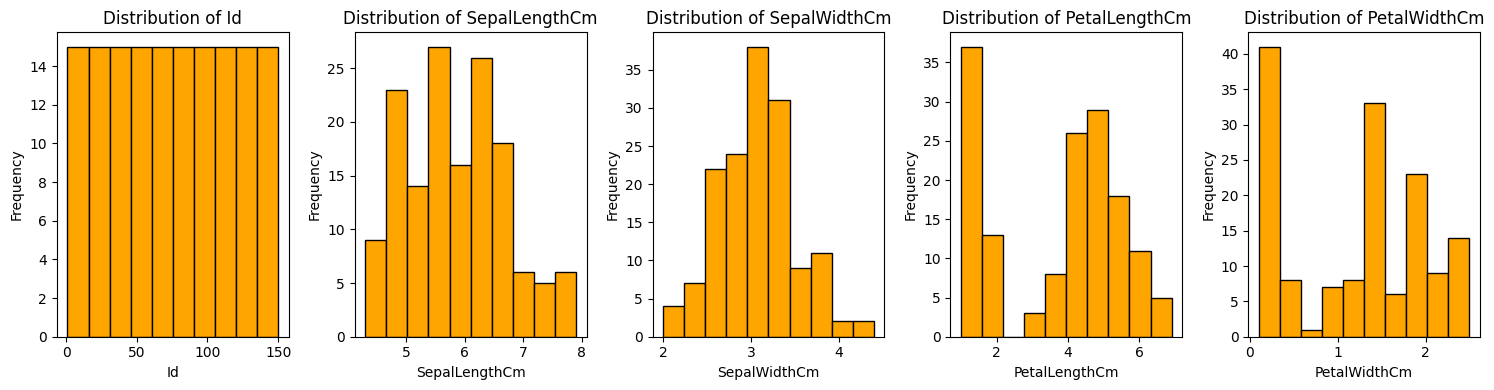

In [22]:
# Exploratory Data Analysis (EDA)
# Visualizing the distribution of species

numerical_columns = iris_data.select_dtypes(include=np.number).columns

num_plots = len(numerical_columns)

fig, axes = plt.subplots(1, num_plots, figsize=(3 * num_plots, 4))

for i, col in enumerate(numerical_columns):
    axes[i].hist(iris_data[col], bins=10, color='orange', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


In [23]:
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

The ANOVA tests were conducted to determine whether the mean values of the flower measurements differ significantly among the three Iris species. For all variables analyzed — SepalWidthCm, PetalLengthCm, and PetalWidthCm — the ANOVA results show very small p-values (< 0.05), indicating that there are statistically significant differences among the species in each of these features.
For SepalWidthCm, the F-statistic was 47.36 with a p-value of approximately 1.33×10⁻¹⁶, confirming a significant variation in sepal width among species. The Tukey HSD post-hoc test further revealed that all pairwise comparisons (Setosa vs. Versicolor, Setosa vs. Virginica, and Versicolor vs. Virginica) were significantly different (p < 0.05). This means each species has a distinct average sepal width, with Iris-setosa generally having a wider sepal compared to the others.
In the case of PetalLengthCm, the F-statistic was extremely large (1179.03) and the p-value nearly zero (3.05×10⁻⁹¹), showing a very strong difference among species. Tukey’s test confirmed that all pairs differ significantly, with Iris-setosa having the smallest petals, Iris-versicolor having intermediate petal lengths, and Iris-virginica having the longest petals.
Similarly, for PetalWidthCm, the ANOVA (F = 959.32, p ≈ 4.38×10⁻⁸⁵) shows highly significant differences among species. Tukey’s results again indicate that all species differ significantly from one another, following the same pattern — Setosa < Versicolor < Virginica in terms of petal width.
In summary, the statistical results confirm that the Iris species differ significantly in their sepal width, petal length, and petal width, with petal-related features showing the strongest separation. These findings support the idea that petal dimensions are the most effective variables for distinguishing between Iris species in classification tasks.

In [24]:
# Testing significance of the features using ANOVA

features = numerical_columns.tolist()
features.remove('Id')  # Remove Id column if present
features

for i in features:
    model = ols(f'{i} ~ C(Species)', data=iris_data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f'ANOVA results for {i}:')
    print(anova_table)
    print('\n')

    # Post-hoc test using Tukey's HSD
    tukey = pairwise_tukeyhsd(endog=iris_data[i], groups=iris_data['Species'], alpha=0.05)
    print(tukey)
    print('\n')

ANOVA results for SepalLengthCm:
               sum_sq     df           F        PR(>F)
C(Species)  63.212133    2.0  119.264502  1.669669e-31
Residual    38.956200  147.0         NaN           NaN


        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1          group2     meandiff p-adj lower  upper  reject
-------------------------------------------------------------------
    Iris-setosa Iris-versicolor     0.93   0.0 0.6862 1.1738   True
    Iris-setosa  Iris-virginica    1.582   0.0 1.3382 1.8258   True
Iris-versicolor  Iris-virginica    0.652   0.0 0.4082 0.8958   True
-------------------------------------------------------------------


ANOVA results for SepalWidthCm:
             sum_sq     df          F        PR(>F)
C(Species)  10.9776    2.0  47.364461  1.327917e-16
Residual    17.0350  147.0        NaN           NaN


         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj  lower   upper 

In [26]:
# machine learning model to classify the species based on the features
# Encoding the target variable
label_encoder = LabelEncoder()
iris_data['Species'] = label_encoder.fit_transform(iris_data['Species'])
X = iris_data[features]
y = iris_data['Species']
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Training the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
# Making predictions
y_pred = clf.predict(X_test)
# Evaluating the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


The model achieved an accuracy of 100%, meaning it correctly classified all 30 test samples into their respective categories. The classification report shows perfect scores (1.00) for precision, recall, and F1-score across all three classes (0, 1, and 2), indicating that the model made no false positives or false negatives. The confusion matrix further confirms this, as all predictions lie along the diagonal with no misclassifications — each class was predicted exactly as it should be (10, 9, and 11 samples correctly classified). This suggests the model fits the data extremely well, though such perfect performance might also indicate potential overfitting if the dataset is small or too simple.